# UHD

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uhd # Requer instalação do driver da Ettus/NI USRP

def gerar_sinal_baseband(freq_sinal, taxa_amostragem, duracao, tipo='tone'):
    """
    Gera amostras complexas (I/Q) para o bloco de Software do RDS.
    """
    t = np.arange(0, duracao, 1/taxa_amostragem)
    
    if tipo == 'tone':
        # Gera um tom puro (exponencial complexa)
        # I = cos, Q = sin
        amostras = np.exp(1j * 2 * np.pi * freq_sinal * t)
        
    elif tipo == 'ruido':
        # Simulação de canal AWGN [cite: 44]
        amostras = (np.random.normal(0, 1, len(t)) + 
                    1j * np.random.normal(0, 1, len(t))) / np.sqrt(2)
    
    # Normalização para evitar saturação no DAC da USRP
    amostras = amostras / np.max(np.abs(amostras)) * 0.9
    return amostras.astype(np.complex64)

def transmitir_usrp(amostras, freq_central, ganho, taxa_amostragem):
    """
    Interface com o Hardware USRP (NI 2901 ou 2920)[cite: 89].
    """
    # Configuração da USRP (Pseudo-código da lib UHD)
    usrp = uhd.usrp_sink(
        ",".join(("addr=192.168.10.2", "")), # Endereço IP padrão da USRP 2920
        uhd.stream_args(cpu_format="fc32", otw_format="sc16", channels=range(1)),
    )
    
    usrp.set_samp_rate(taxa_amostragem)
    usrp.set_center_freq(freq_central, 0)
    usrp.set_gain(ganho, 0)
    
    # Envio das amostras para o buffer do hardware
    usrp.send(amostras)
    print(f"Transmitindo em {freq_central/1e6} MHz com ganho {ganho}dB")

# --- Parâmetros do Projeto ---
# A USRP 2920 suporta banda de 20MHz [cite: 92] e a 2901 até 56MHz[cite: 90].
fs = 1e6           # 1 MS/s
fc = 900e6         # 900 MHz (faixa permitida no trabalho [cite: 44])
duracao = 1.0      # 1 segundo

# 1. Gerar Sinal (Domínio Digital)
sinal_iq = gerar_sinal_baseband(freq_sinal=10e3, taxa_amostragem=fs, duracao=duracao)

# Visualização rápida (apenas I e Q)
plt.figure(figsize=(10, 4))
plt.plot(np.real(sinal_iq[:100]), label='In-Phase (I)')
plt.plot(np.imag(sinal_iq[:100]), label='Quadrature (Q)')
plt.title('Sinal em Banda Base (Primeiras 100 amostras)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Transmissão (Descomente se tiver a USRP conectada)
# transmitir_usrp(sinal_iq, freq_central=fc, ganho=50, taxa_amostragem=fs)

/home/deivid/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


ModuleNotFoundError: No module named 'uhd'

In [1]:
import uhd
usrp = uhd.usrp.MultiUSRP()
samples = usrp.recv_num_samps(10000, 100e6, 1e6, [0], 50)
print(samples[0:10])

ModuleNotFoundError: No module named 'uhd'

# GNUradio

## BPSK com Hardware

In [ ]:
#!/usr/bin/env python3
import numpy as np
from gnuradio import gr, blocks, digital, uhd
import time

class BPSK_Text_Transmitter(gr.top_block):
    def __init__(self, filepath, samp_rate=500e3, center_freq=915e6, gain=40):
        gr.top_block.__init__(self)

        # --- Load text file ---
        with open(filepath, "r", encoding="utf-8") as f:
            text = f.read()

        # Convert text → bits
        bits = np.unpackbits(np.frombuffer(text.encode("utf-8"), dtype=np.uint8))

        # Create GNU Radio blocks
        self.src = blocks.vector_source_b(bits.tolist(), repeat=False)

        # BPSK Modulator (constellation: 0 → -1, 1 → +1)
        self.mod = digital.chunks_to_symbols_bc([ -1+0j, 1+0j ])

        self.usrp = blocks.file_sink(...)
        # USRP Sink
        # self.usrp = uhd.usrp_sink(
        #     ",".join(("addr=192.168.10.2", "")),
        #     uhd.stream_args(cpu_format="fc32", channels=[0]),
        # )

        self.usrp.set_samp_rate(samp_rate)
        self.usrp.set_center_freq(center_freq)
        self.usrp.set_gain(gain)

        # Connect graph
        self.connect(self.src, self.mod, self.usrp)


if __name__ == "__main__":
    filepath = "/home/deivid/msg.txt"     # arquivo a transmitir
    tb = BPSK_Text_Transmitter(filepath=filepath
                               , samp_rate=500e3
                             , center_freq=915e6
                             , gain=40)

    print("\nTransmitindo arquivo...\n")
    tb.start()
    time.sleep(3)   # transmite por 3 segundos
    tb.stop()
    tb.wait()
    print("Transmissão finalizada.")


[INFO] [UHD] linux; GNU C++ version 11.2.0; Boost_107400; UHD_4.1.0.5-3


RuntimeError: LookupError: KeyError: No devices found for ----->
Device Address:
    addr: 192.168.10.2


## BPSK sem hardware

In [7]:
#!/usr/bin/env python3
import numpy as np
from gnuradio import gr, blocks, digital

class BPSK_Text_Transmitter(gr.top_block):
    def __init__(self, filepath, samp_rate=500e3):
        gr.top_block.__init__(self)

        # --- Load text file ---
        with open(filepath, "r", encoding="utf-8") as f:
            text = f.read()

        # Convert text → bits
        bits = np.unpackbits(
            np.frombuffer(text.encode("utf-8"), dtype=np.uint8)
        )

        # Blocks
        self.src = blocks.vector_source_b(bits.tolist(), repeat=False)

        # BPSK modulator
        self.mod = digital.chunks_to_symbols_bc([ -1+0j, 1+0j ])

        # Optional: Save I/Q to file for analysis
        self.sink = blocks.file_sink(gr.sizeof_gr_complex, "bpsk_output.dat")

        # Connect
        self.connect(self.src, self.mod, self.sink)


if __name__ == "__main__":
    filepath = "/home/deivid/msg.txt"     # arquivo a transmitir
    tb = BPSK_Text_Transmitter(filepath)
    print("Simulando transmissão BPSK...")
    tb.run()
    print("Arquivo gerado: bpsk_output.dat")


Simulando transmissão BPSK...
Arquivo gerado: bpsk_output.dat


### Analisar arquivo criado

Número de amostras: 80000
Primeiras amostras: [-1.+0.j -1.+0.j  1.+0.j  1.+0.j -1.+0.j -1.+0.j -1.+0.j -1.+0.j -1.+0.j
 -1.+0.j]


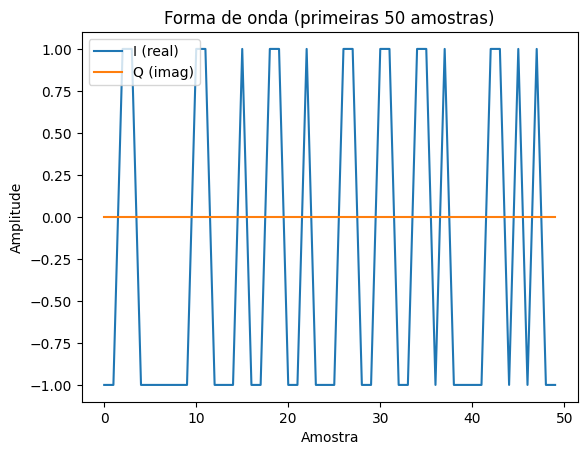

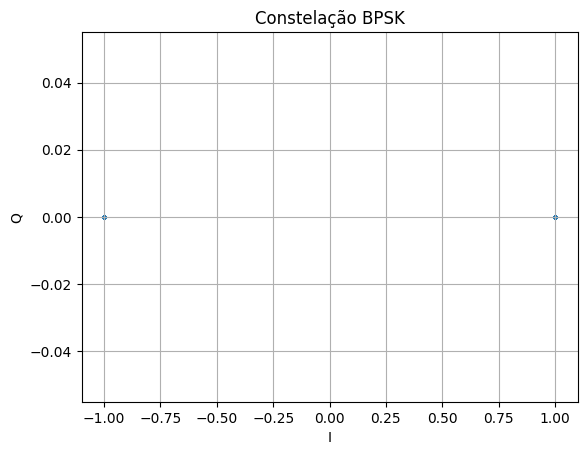

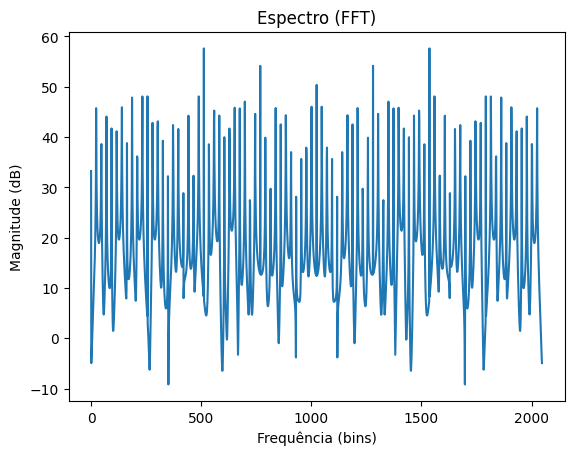

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Carregar arquivo
data = np.fromfile("bpsk_output.dat", dtype=np.complex64)

print("Número de amostras:", len(data))
print("Primeiras amostras:", data[:10])

# Plotar waveform
plt.figure()
plt.plot(data.real[:50], label="I (real)")
plt.plot(data.imag[:50], label="Q (imag)")
plt.legend()
plt.title("Forma de onda (primeiras 50 amostras)")
plt.xlabel("Amostra")
plt.ylabel("Amplitude")
plt.show()

# Plotar constelação
plt.figure()
plt.scatter(data.real[::20], data.imag[::20], s=2)
plt.title("Constelação BPSK")
plt.xlabel("I")
plt.ylabel("Q")
plt.grid(True)
plt.show()

# Plotar FFT
fft = np.fft.fftshift(np.fft.fft(data[:2048]))
plt.figure()
plt.plot(20*np.log10(np.abs(fft)))
plt.title("Espectro (FFT)")
plt.xlabel("Frequência (bins)")
plt.ylabel("Magnitude (dB)")
plt.show()


## Receptor BPSK

In [10]:
import numpy as np

# Carrega sinal
data = np.fromfile("bpsk_output.dat", dtype=np.complex64)

# Demodulação BPSK:  >=0 → 1, <0 → 0
bits = (data.real >= 0).astype(np.uint8)

# Agrupa em bytes
bits = bits[: (len(bits)//8)*8]  # múltiplo de 8
bytes_out = np.packbits(bits)

# Converte para texto
try:
    texto = bytes_out.tobytes().decode("utf-8", errors="ignore")
    print("Texto decodificado:")
    print(texto)
except Exception as e:
    print("Erro ao decodificar:", e)


Texto decodificado:
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0123456789
0

### BER

In [13]:
#!/usr/bin/env python3
import numpy as np
from pathlib import Path
from scipy.signal import correlate

orig_path = Path("msg.txt")
iq_path = Path("bpsk_output.dat")

if not orig_path.exists() or not iq_path.exists():
    raise SystemExit("Coloque msg.txt e bpsk_output.dat no mesmo diretório e rode este script.")

# Carrega TX bits
orig_bytes = orig_path.read_bytes()
tx_bits = np.unpackbits(np.frombuffer(orig_bytes, dtype=np.uint8))

# Converte bits 0->-1, 1->+1 (NRZ) para correlação
tx_nrz = (tx_bits.astype(np.int8) * 2) - 1  # 0->-1, 1->+1

# Carrega I/Q rx
iq = np.fromfile(str(iq_path), dtype=np.complex64)
rx_real = iq.real

if len(rx_real) < 10:
    raise SystemExit("Arquivo RX muito pequeno.")

# Para reduzir custo, limite use de segmentos (se são longos)
max_tx_search = min(len(tx_nrz), 200000)  # ajusta se quiser
tx_segment = tx_nrz[:max_tx_search]

# Faz correlação cruzada (nota: custo O(N log N) internamente)
corr = correlate(rx_real, tx_segment, mode='valid')
# index do pico em 'valid' corresponde a deslocamento do início de tx_segment em rx_real
best_idx = np.argmax(np.abs(corr))
offset = best_idx  # número de amostras em rx antes do início do segmento TX

print("Deslocamento estimado (amostras):", offset)
# Agora compare a partir daí
available = len(rx_real) - offset
compare_bits = min(len(tx_bits), available)
if compare_bits <= 0:
    raise SystemExit("Sem dados suficientes após alinhamento.")

# Extraia rx_bits a partir do offset
rx_bits = (rx_real[offset:offset+compare_bits] >= 0).astype(np.uint8)
tx_cmp = tx_bits[:compare_bits]

errors = np.sum(tx_cmp != rx_bits)
ber = errors / compare_bits

print("Bits comparados:", compare_bits)
print("Erros de bit:  ", errors)
print("BER:           ", f"{ber:.6e}", f"({ber*100:.6f}%)")

# Salva a mensagem decodificada (múltiplos de 8)
n_bytes = (compare_bits // 8)
rx_bytes = np.packbits(rx_bits[:n_bytes*8])
Path("mensagem_decodificada_alinhada.txt").write_bytes(rx_bytes.tobytes())
print("Texto decodificado salvo em: mensagem_decodificada_alinhada.txt")


Deslocamento estimado (amostras): 0
Bits comparados: 80000
Erros de bit:   0
BER:            0.000000e+00 (0.000000%)
Texto decodificado salvo em: mensagem_decodificada_alinhada.txt


## Imagem

7 – A transmissão de imagem colorida RGB 24 bits, 100x100 pixels. O usuário escolhe a imagem a
transmitir. Define a largura de banda máxima exigida para transmissão de modo que a imagem seja
transmitida em no máximo 3 segundos


In [ ]:
from PIL import Image
import numpy as np

# Carrega imagem e converte para bytes puros
img = Image.open("/home/deivid/radio-frequency/input_data/random_pb.jpg").resize((100, 100)).convert('RGB')
dados = np.array(img)
dados.tofile("transmissao_in.bin") # Arquivo para o GNU Radio ler
print(f"Tamanho do arquivo: {len(dados.tobytes())} bytes")

## Video